In [1]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

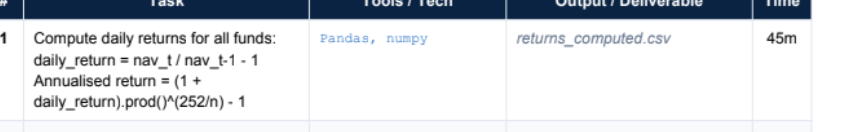

In [ ]:
import pandas as pd
import numpy as np

# Load NAV data
nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# -----------------------------
# Compute Daily Returns
# Formula:
# daily_return = NAV_t / NAV_t-1 - 1
# -----------------------------

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# -----------------------------
# Compute Annualized Returns
# Formula:
# ((1+r1)(1+r2)...(1+rn))^(252/n) - 1
# -----------------------------

annual_returns = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    n = len(returns)

    annualized_return = (
        (1 + returns).prod()
    ) ** (252 / n) - 1

    annual_returns.append([
        code,
        annualized_return * 100
    ])

# Create DataFrame
returns_df = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annualized_return_pct"
    ]
)

# Display results
print(returns_df.head())

# Save CSV
returns_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/returns_computed.csv",
    index=False
)



# Optional: show NAV data with daily returns
print("\nSample Daily Returns:")
print(
    nav[
        ["amfi_code", "date", "nav", "daily_return"]
    ].head(10)
)

   amfi_code  annualized_return_pct
0     100016               2.543487
1     100025               4.298652
2     100033              28.927866
3     101206              22.626535
4     101207               7.650159

Sample Daily Returns:
      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


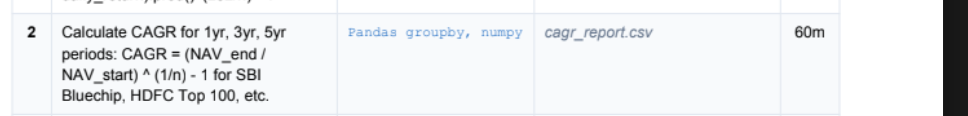

In [ ]:
import pandas as pd
import numpy as np

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

# -------------------------
# Load Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

cagr_results = []

# -------------------------
# Calculate CAGR
# -------------------------

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest_date = group["date"].max()

    result = {"amfi_code": code}

    # 1-Year CAGR
    one_year = group[
        group["date"] >= latest_date - pd.DateOffset(years=1)
    ]

    if len(one_year) > 1:

        start_nav = one_year["nav"].iloc[0]
        end_nav = one_year["nav"].iloc[-1]

        cagr_1yr = (
            (end_nav / start_nav) ** (1/1) - 1
        ) * 100

        result["cagr_1yr_pct"] = round(cagr_1yr, 2)

    else:
        result["cagr_1yr_pct"] = np.nan

    # 3-Year CAGR
    three_year = group[
        group["date"] >= latest_date - pd.DateOffset(years=3)
    ]

    if len(three_year) > 1:

        start_nav = three_year["nav"].iloc[0]
        end_nav = three_year["nav"].iloc[-1]

        cagr_3yr = (
            (end_nav / start_nav) ** (1/3) - 1
        ) * 100

        result["cagr_3yr_pct"] = round(cagr_3yr, 2)

    else:
        result["cagr_3yr_pct"] = np.nan

    # 5-Year CAGR
    five_year = group[
        group["date"] >= latest_date - pd.DateOffset(years=5)
    ]

    if len(five_year) > 1:

        start_nav = five_year["nav"].iloc[0]
        end_nav = five_year["nav"].iloc[-1]

        years = (
            (five_year["date"].iloc[-1]
             - five_year["date"].iloc[0]).days
        ) / 365.25

        cagr_5yr = (
            (end_nav / start_nav) ** (1/years) - 1
        ) * 100

        result["cagr_5yr_pct"] = round(cagr_5yr, 2)

    else:
        result["cagr_5yr_pct"] = np.nan

    cagr_results.append(result)

# -------------------------
# Create CAGR DataFrame
# -------------------------

cagr_df = pd.DataFrame(cagr_results)

# -------------------------
# Merge Fund Information
# -------------------------

cagr_df = cagr_df.merge(
    fund[
        ["amfi_code", "scheme_name", "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

# Reorder Columns
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
]

# Sort by 3-Year CAGR
cagr_df = cagr_df.sort_values(
    "cagr_3yr_pct",
    ascending=False
)

# Show Top Funds
print(cagr_df.head(10))

# Save Report
cagr_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/cagr_report.csv",
    index=False
)


    amfi_code                                        scheme_name  \
16     119094                Axis Midcap Fund - Regular - Growth   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   
39     149324              DSP Small Cap Fund - Regular - Growth   

                  fund_house  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct  
16          Axis Mutual Fund         22.26         35.11         28.21  
34            Mirae Asset MF         20.36         34.00         30.97  
24       ICICI Prudential MF    

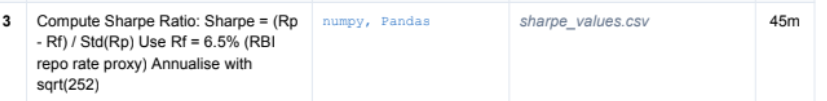

In [ ]:
import pandas as pd
import numpy as np

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# -------------------------
# Daily Returns
# -------------------------

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# -------------------------
# Load Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# Sharpe Calculation
# -------------------------

rf = 0.065
daily_rf = rf / 252

results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    std_return = returns.std()

    if std_return != 0:

        sharpe = (
            (avg_return - daily_rf)
            / std_return
        ) * np.sqrt(252)

    else:
        sharpe = np.nan

    results.append(
        [code, round(sharpe, 4)]
    )

# -------------------------
# Create DataFrame
# -------------------------

sharpe_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

# -------------------------
# Add Fund Names
# -------------------------

sharpe_df = sharpe_df.merge(
    fund[
        ["amfi_code",
         "scheme_name",
         "fund_house"]
    ],
    on="amfi_code",
    how="left"
)

# Reorder Columns
sharpe_df = sharpe_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "sharpe_ratio"
    ]
]

# Sort Best to Worst
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

print(sharpe_df.head(10))

# -------------------------
# Save CSV
# -------------------------

sharpe_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sharpe_values.csv",
    index=False
)



    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   

                  fund_house  sharpe_ratio  
34            Mirae Asset MF        1.4483  
30         Kotak Mahindra MF        1.3067  
36            Mirae Asset MF        1.2349  
19           SBI Mutual Fund        1.2083  
25       ICICI Prudential 

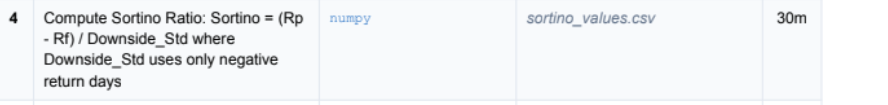

In [ ]:
import pandas as pd
import numpy as np

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# -------------------------
# Daily Returns
# -------------------------

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# -------------------------
# Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# Sortino Calculation
# -------------------------

rf = 0.065
daily_rf = rf / 252

results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    avg_return = returns.mean()

    # Only negative returns
    downside_returns = returns[
        returns < 0
    ]

    downside_std = downside_returns.std()

    if (
        downside_std is not None
        and not np.isnan(downside_std)
        and downside_std != 0
    ):

        sortino = (
            (avg_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    results.append(
        [code, round(sortino, 4)]
    )

# -------------------------
# DataFrame
# -------------------------

sortino_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

# -------------------------
# Add Fund Info
# -------------------------

sortino_df = sortino_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "sortino_ratio"
    ]
]

# Best Funds First
sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

print(sortino_df.head(10))

# -------------------------
# Save CSV
# -------------------------

sortino_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sortino_values.csv",
    index=False
)



    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   

                  fund_house  sortino_ratio  
34            Mirae Asset MF         2.3856  
30         Kotak Mahindra MF         2.3643  
36            Mirae Asset MF         2.1469  
19           SBI Mutual Fund         2.1403  
25       ICICI Pruden

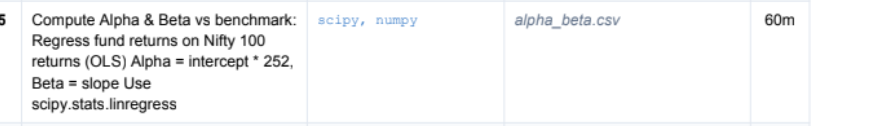

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Daily Fund Returns
nav["fund_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# -------------------------
# Load Benchmark Data
# -------------------------

benchmark = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Select NIFTY100
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

# Daily Benchmark Returns
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

# -------------------------
# Load Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# Alpha & Beta Calculation
# -------------------------

results = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group[
            ["date", "fund_return"]
        ],
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["fund_return"]
        )

        beta = regression.slope

        alpha = (
            regression.intercept * 252
        )

        results.append([
            code,
            round(alpha, 4),
            round(beta, 4)
        ])

# -------------------------
# Create DataFrame
# -------------------------

alpha_beta_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

# Add Fund Information
alpha_beta_df = alpha_beta_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "alpha",
        "beta"
    ]
]

# Sort by Alpha
alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

print(alpha_beta_df.head(10))

# Save Output
alpha_beta_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/alpha_beta.csv",
    index=False
)



    amfi_code                                        scheme_name  \
21     119598         SBI Small Cap Fund - Regular Plan - Growth   
39     149324              DSP Small Cap Fund - Regular - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
16     119094                Axis Midcap Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   

             fund_house   alpha    beta  
21      SBI Mutual Fund  0.3034 -0.0232  
39      DSP Mutual Fund  0.3006  0.0115  
25  ICICI Prudential MF  0.2926  0.0005  
36       Mirae Asset MF  0.2827  0.0181  
30    Kotak Mahindra MF  0.2733 -0.0228  

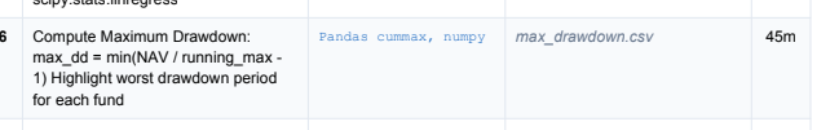

In [ ]:
import pandas as pd
import numpy as np

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# -------------------------
# Load Fund Master
# -------------------------

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

results = []

# -------------------------
# Maximum Drawdown
# -------------------------

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = (
        group["nav"].cummax()
    )

    # Drawdown
    group["drawdown"] = (
        group["nav"] /
        group["running_max"]
        - 1
    )

    # Worst drawdown
    worst_idx = group["drawdown"].idxmin()

    max_dd = group.loc[
        worst_idx,
        "drawdown"
    ]

    worst_date = group.loc[
        worst_idx,
        "date"
    ]

    results.append([
        code,
        round(max_dd * 100, 2),
        worst_date
    ])

# -------------------------
# Create DataFrame
# -------------------------

max_dd_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "max_drawdown_pct",
        "worst_drawdown_date"
    ]
)

# Add Fund Information
max_dd_df = max_dd_df.merge(
    fund[
        [
            "amfi_code",
            "scheme_name",
            "fund_house"
        ]
    ],
    on="amfi_code",
    how="left"
)

# Reorder Columns
max_dd_df = max_dd_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "max_drawdown_pct",
        "worst_drawdown_date"
    ]
]

# Sort Worst First
max_dd_df = max_dd_df.sort_values(
    "max_drawdown_pct"
)

print(max_dd_df.head(10))

# Save CSV
max_dd_df.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/max_drawdown.csv",
    index=False
)



    amfi_code                                     scheme_name  \
22     119599       SBI Small Cap Fund - Direct Plan - Growth   
17     119095          Axis Small Cap Fund - Regular - Growth   
4      101207          ABSL Small Cap Fund - Regular - Growth   
39     149324           DSP Small Cap Fund - Regular - Growth   
21     119598      SBI Small Cap Fund - Regular Plan - Growth   
7      102886             UTI Mid Cap Fund - Regular - Growth   
0      100016       HDFC Top 100 Fund - Regular Plan - Growth   
29     120842   Kotak Emerging Equity Fund - Regular - Growth   
11     118634  Nippon India Small Cap Fund - Regular - Growth   
15     119093            Axis Bluechip Fund - Direct - Growth   

                  fund_house  max_drawdown_pct worst_drawdown_date  
22           SBI Mutual Fund            -52.57          2025-10-28  
17          Axis Mutual Fund            -51.68          2026-05-11  
4   Aditya Birla Sun Life MF            -35.45          2026-05-11  
39      

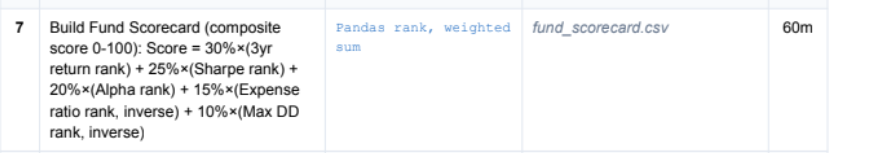

In [ ]:
import pandas as pd

# -------------------------
# Load Files
# -------------------------

cagr = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/cagr_report.csv"
)

sharpe = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/sharpe_values.csv"
)

alpha_beta = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/alpha_beta.csv"
)

max_dd = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/max_drawdown.csv"
)

fund = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/01_fund_master.csv"
)

# -------------------------
# Merge Everything
# -------------------------

scorecard = (
    cagr.merge(
        sharpe[["amfi_code", "sharpe_ratio"]],
        on="amfi_code"
    )
    .merge(
        alpha_beta[["amfi_code", "alpha"]],
        on="amfi_code"
    )
    .merge(
        max_dd[["amfi_code", "max_drawdown_pct"]],
        on="amfi_code"
    )
    .merge(
        fund[
            ["amfi_code",
             "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

# -------------------------
# Create Ranks
# -------------------------

scorecard["return_rank"] = (
    scorecard["cagr_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

# Lower Expense Ratio is Better
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

# Smaller Drawdown is Better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(ascending=False)
)

# -------------------------
# Composite Score
# -------------------------

scorecard["score"] = (
    0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

# Convert to 0-100 Scale
scorecard["score"] = (
    scorecard["score"].max()
    - scorecard["score"]
) / (
    scorecard["score"].max()
    - scorecard["score"].min()
) * 100

# -------------------------
# Final Ranking
# -------------------------

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard["fund_rank"] = range(
    1,
    len(scorecard) + 1
)

print(
    scorecard[
        [
            "fund_rank",
            "scheme_name",
            "score"
        ]
    ].head(10)
)

# -------------------------
# Save Output
# -------------------------

scorecard.to_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/fund_scorecard.csv",
    index=False
)



    fund_rank                                        scheme_name       score
1           1      Mirae Asset Large Cap Fund - Regular - Growth  100.000000
4           2           ICICI Pru Midcap Fund - Regular - Growth   94.439618
6           3             Kotak Flexicap Fund - Regular - Growth   94.092094
3           4  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   92.354474
2           5          ICICI Pru Bluechip Fund - Direct - Growth   91.311903
0           6                Axis Midcap Fund - Regular - Growth   87.141616
5           7          SBI Bluechip Fund - Regular Plan - Growth   84.100782
7           8      Mirae Asset Tax Saver Fund - Regular - Growth   82.536924
8           9      ABSL Frontline Equity Fund - Regular - Growth   74.891399
11         10         SBI Small Cap Fund - Regular Plan - Growth   73.761946


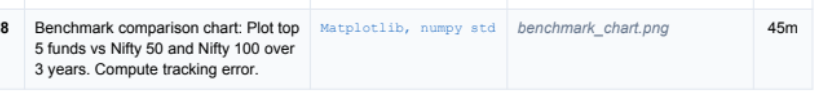

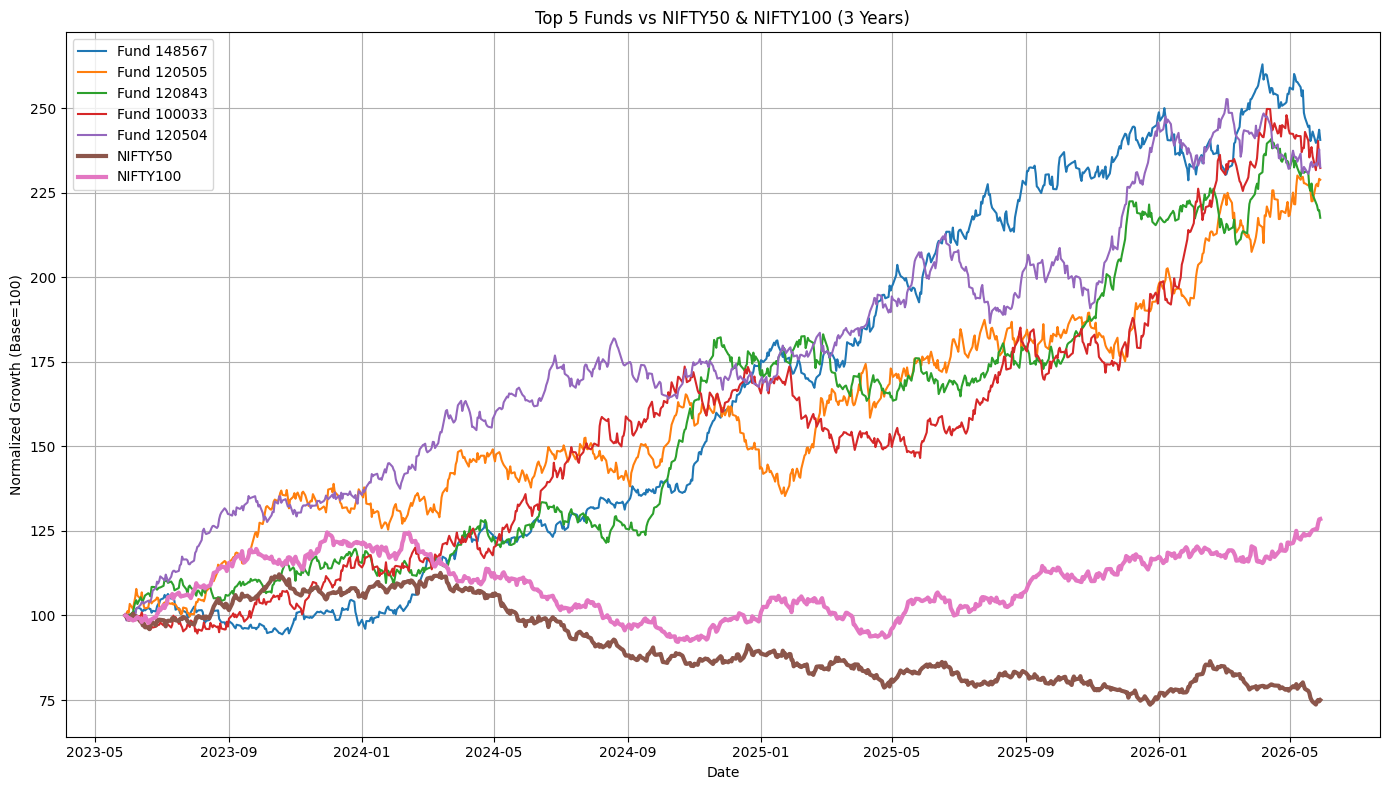

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load NAV Data
# -------------------------

nav = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/clean_nav.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

# -------------------------
# Load Benchmark Data
# -------------------------

benchmark = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# -------------------------
# Top 5 Funds
# -------------------------

scorecard = pd.read_csv(
    "/content/drive/MyDrive/bluestock_mf_capstone/data/processed/fund_scorecard.csv"
)

top5_codes = (
    scorecard.head(5)["amfi_code"]
    .tolist()
)

# -------------------------
# Last 3 Years Data
# -------------------------

cutoff = nav["date"].max() - pd.DateOffset(years=3)

nav = nav[
    nav["date"] >= cutoff
]

benchmark = benchmark[
    benchmark["date"] >= cutoff
]

# -------------------------
# Benchmark Series
# -------------------------

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

# Normalize Benchmarks
nifty50_norm = (
    nifty50["close_value"]
    / nifty50["close_value"].iloc[0]
) * 100

nifty100_norm = (
    nifty100["close_value"]
    / nifty100["close_value"].iloc[0]
) * 100

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(14,8))

# Top 5 Funds
for code in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    normalized_nav = (
        fund_data["nav"]
        / fund_data["nav"].iloc[0]
    ) * 100

    plt.plot(
        fund_data["date"],
        normalized_nav,
        label=f"Fund {code}"
    )

# Nifty50
plt.plot(
    nifty50["date"],
    nifty50_norm,
    linewidth=3,
    label="NIFTY50"
)

# Nifty100
plt.plot(
    nifty100["date"],
    nifty100_norm,
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)"
)

plt.xlabel("Date")
plt.ylabel("Normalized Growth (Base=100)")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/bluestock_mf_capstone/reports/benchmark_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Tracking Error Calculation

In [ ]:
tracking_results = []

for code in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == code
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["fund_return"] = (
        fund_data["nav"]
        .pct_change()
    )

    benchmark_ret = nifty100.copy()

    benchmark_ret["benchmark_return"] = (
        benchmark_ret["close_value"]
        .pct_change()
    )

    merged = pd.merge(
        fund_data[
            ["date", "fund_return"]
        ],
        benchmark_ret[
            ["date", "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["fund_return"]
         - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append(
        [code, tracking_error]
    )

tracking_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

print(tracking_df)

   amfi_code  tracking_error
0     148567        0.187974
1     120505        0.232661
2     120843        0.206540
3     100033        0.224976
4     120504        0.187299
